# D200, Problem Set 3: Reinforcement Learning

Due: 5 March 2026 [here](https://classroom.github.com/a/J6Ayhj4S) in
groups of up to 2.

Stefan Bucher

This problem set introduces reinforcement learning through three
economic applications from IO and quantitative marketing. You will
progress from multi-armed bandits (ad-channel testing) to tabular
Q-learning (airline revenue management) to Deep Q-Networks
(within-session content personalisation). Each problem is
self-contained: the key RL concepts are explained before you need them.

# Problem 1: Multi-Armed Bandits for Ad Channel Selection

**The exploration-exploitation dilemma.** Suppose a firm can advertise
through several marketing channels but doesn’t know which channel
converts customers most effectively. If the firm always uses the channel
that *looks* best so far (exploitation), it might miss a better option
it hasn’t tried enough. If it keeps experimenting with all channels
equally (exploration), it wastes budget on poor performers. *Multi-armed
bandits* formalise this tradeoff: an agent repeatedly chooses one of $K$
“arms” (here, ad channels), observes a reward (conversion or not), and
must learn which arm is best while minimising total reward lost from
suboptimal choices. This is the simplest reinforcement learning setting
— there is no state, no dynamics, just a repeated decision under
uncertainty.

## Environment

The `AdChannelBandit` below simulates $K = 5$ marketing channels. Each
time you select a channel, a customer either converts (reward $= 1$) or
does not (reward $= 0$), drawn from a Bernoulli distribution with an
unknown channel-specific conversion rate. The firm’s goal is to maximise
total conversions over $T$ rounds.

In [2]:
class AdChannelBandit:
    """K-armed bandit for ad channel selection with Bernoulli rewards."""
    
    def __init__(self):
        self.channels = ["Email", "Social Media", "Display Ads", "Search", "Influencer"]
        self.K = len(self.channels)
        self._rates = np.array([0.08, 0.15, 0.12, 0.25, 0.05])
    
    def pull(self, arm):
        """Select a channel and observe conversion (1) or not (0)."""
        return np.random.binomial(1, self._rates[arm])
    
    def optimal_arm(self):
        """Index of the channel with the highest true conversion rate."""
        return np.argmax(self._rates)
    
    def expected_reward(self, arm):
        """True conversion rate of the given channel (used for regret calculation)."""
        return self._rates[arm]

bandit = AdChannelBandit()
print("Channels:", bandit.channels)
print(f"Number of arms (K): {bandit.K}")

Channels: ['Email', 'Social Media', 'Display Ads', 'Search', 'Influencer']
Number of arms (K): 5

**(1a)** As a baseline, run a **random policy** that selects a channel
uniformly at random each round for $T = 2000$ rounds. Plot:

1.  **Cumulative reward** (total conversions over time)
2.  **Cumulative regret** over time

**Regret** measures the cost of not always pulling the best arm. Define
per-round regret as $p^* - p_{a_t}$, where $p^* = \max_k p_k$ is the
best channel’s true conversion rate and $p_{a_t}$ is the conversion rate
of the channel chosen at round $t$. Cumulative regret sums this over all
rounds: $$R_T = \sum_{t=1}^T \left(p^* - p_{a_t}\right)$$

*Hint:* a random policy has constant expected per-round regret, so
cumulative regret grows linearly.

``` python
def run_random(bandit, T=2000):
    """Run a random policy for T rounds.
    
    Returns:
        rewards: array of length T, reward at each round (0 or 1)
        arms_played: array of length T, index of arm chosen each round
    """
    # TODO: implement
    pass

# Run the random policy and plot cumulative reward and cumulative regret
```

**(1b)** Implement the following three bandit algorithms and compare
them (plus the random baseline) on a single cumulative regret plot over
$T = 2000$ rounds, averaged over 50 independent runs.

1.  **$\epsilon$-greedy ($\epsilon = 0.1$):** With probability
    $\epsilon$, choose a random arm; otherwise choose the arm with the
    highest empirical mean reward. Update means incrementally:
    $\bar{r}_a \leftarrow \bar{r}_a + \frac{1}{n_a}(r_t - \bar{r}_a)$.
2.  **UCB1 ($c = 2$):** Pull each arm once, then choose
    $\arg\max_a \left[\bar{r}_a + c\sqrt{\frac{\ln t}{n_a}}\right]$
    where $n_a$ is the number of times arm $a$ has been pulled.
3.  **Thompson Sampling:** Maintain a $\text{Beta}(\alpha_a, \beta_a)$
    posterior for each arm (initialised at $\text{Beta}(1,1)$, the
    uniform prior). Each round, sample
    $\theta_a \sim \text{Beta}(\alpha_a, \beta_a)$ for every arm and
    pull $\arg\max_a \theta_a$. On observing reward $r_t \in \{0,1\}$,
    update: $\alpha_a \leftarrow \alpha_a + r_t$,
    $\beta_a \leftarrow \beta_a + (1 - r_t)$.

Each function should return `(rewards, arms_played)` arrays of length
$T$, just like `run_random`.

``` python
def epsilon_greedy(bandit, T=2000, epsilon=0.1):
    """Epsilon-greedy algorithm."""
    # TODO: implement
    pass

def ucb1(bandit, T=2000, c=2.0):
    """UCB1 algorithm."""
    # TODO: implement
    pass

def thompson_sampling(bandit, T=2000):
    """Thompson Sampling with Beta(1,1) priors."""
    # TODO: implement
    pass

# Run each algorithm for 50 independent runs and plot average cumulative regret
```

**(1c)** Answer the following in 2–3 sentences each (no code needed):

1.  Which of the three algorithms learns fastest (achieves lowest
    cumulative regret)? Why does it outperform the others?
2.  A marketing manager proposes: *“Let’s just test each of the 5
    channels equally for 400 rounds each, then pick the winner.”* What
    is the cumulative regret of this uniform-testing strategy over the
    full $T = 2000$ rounds, and why do adaptive algorithms do better?

# Problem 2: Airline Revenue Management via Reinforcement Learning

In Problem 1 the firm chose prices without state — each round was
independent. Real pricing problems are richer: an airline has a *finite*
number of seats and a *finite* selling horizon, so today’s optimal fare
depends on how many seats remain and how many days are left before
departure. This kind of sequential decision-making under uncertainty is
formalised as a **Markov Decision Process (MDP)**, defined by states
$\mathcal{S}$ (what the agent observes), actions $\mathcal{A}$ (what it
can do), a reward function $R(s,a)$ (immediate payoff), transition
probabilities $P(s'\mid s,a)$ (how the world evolves), and a discount
factor $\gamma\in[0,1]$ (how much the agent values future versus present
rewards).

The key recursive insight is the **Bellman equation**:
$V(s)=\max_a\bigl[\mathbb{E}[r\mid s,a]+\gamma\,\mathbb{E}[V(s')\mid s,a]\bigr]$.
When the model ($P$ and $R$) is known, **value iteration** applies this
equation to every state until convergence, yielding the optimal policy
$\pi^*(s)=\arg\max_a[\cdots]$. When the model is *unknown*,
**Q-learning** learns action-values directly from data using the update
$Q(s,a)\leftarrow Q(s,a)+\alpha\bigl[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\bigr]$
— the agent simply interacts with the environment and refines its
estimates, requiring no knowledge of $P$ or $R$.

## Environment

The `AirlinePricingEnv` below models an airline selling $N=10$ seats on
a flight departing in $T=25$ days (a small state space so that tabular
Q-learning can learn a policy close to the optimal one). Each day the
airline chooses one of five fare classes. One potential passenger
arrives and buys (or not) according to a logit demand model — the same
functional form as PS2’s discrete choice, with
$P(\text{buy})=\frac{1}{1+\exp(-(\alpha+\beta\cdot\text{price}))}$.

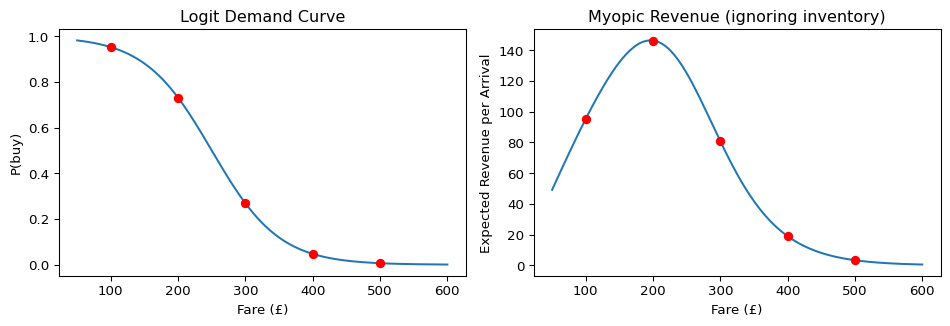

Observation space: MultiDiscrete([11 26])
Action space:      Discrete(5)  (fares = [100 200 300 400 500])
Purchase probs:    {100: 0.953, 200: 0.731, 300: 0.269, 400: 0.047, 500: 0.007}

In [5]:
import gymnasium
from gymnasium import spaces

class AirlinePricingEnv(gymnasium.Env):
    """Airline revenue management environment.

    State: (seats_remaining, days_to_departure)
    Action: one of 5 fare classes
    Reward: fare if passenger buys, 0 otherwise
    Terminal: departure day reached or sold out

    Default: 10 seats, 25 days (small state space so Q-learning can match VI well).
    """

    def __init__(self, max_seats=10, max_days=25, alpha=5.0, beta=-0.02):
        super().__init__()
        self.max_seats = max_seats
        self.max_days = max_days
        self.alpha = alpha
        self.beta = beta
        self.fares = np.array([100, 200, 300, 400, 500])

        self.observation_space = spaces.MultiDiscrete([max_seats + 1, max_days + 1])
        self.action_space = spaces.Discrete(len(self.fares))

    def demand_prob(self, price):
        """P(buy) = 1 / (1 + exp(-(alpha + beta * price)))"""
        return 1.0 / (1.0 + np.exp(-(self.alpha + self.beta * price)))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.seats_remaining = self.max_seats
        self.days_to_departure = self.max_days
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([self.seats_remaining, self.days_to_departure])

    def step(self, action):
        price = self.fares[action]

        if self.seats_remaining > 0:
            p = self.demand_prob(price)
            bought = int(self.np_random.binomial(1, p))
            reward = float(price * bought)
            self.seats_remaining -= bought
        else:
            reward = 0.0

        self.days_to_departure -= 1
        terminated = (self.days_to_departure == 0) or (self.seats_remaining == 0)
        truncated = False

        return self._get_obs(), reward, terminated, truncated, {}

env = AirlinePricingEnv()

price_grid = np.linspace(50, 600, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(price_grid, env.demand_prob(price_grid))
axes[0].scatter(env.fares, env.demand_prob(env.fares), c='red', zorder=5)
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('P(buy)')
axes[0].set_title('Logit Demand Curve')

axes[1].plot(price_grid, price_grid * env.demand_prob(price_grid))
axes[1].scatter(env.fares, env.fares * env.demand_prob(env.fares), c='red', zorder=5)
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Expected Revenue per Arrival')
axes[1].set_title('Myopic Revenue (ignoring inventory)')
plt.tight_layout()
plt.show()

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}  (fares = {env.fares})")
print(f"Purchase probs:    {dict(zip(env.fares, np.round(env.demand_prob(env.fares), 3)))}")

**(2a) MDP formulation.** Write down the components of this MDP:

1.  State space $\mathcal{S}$: what variables define a state? How large
    is $|\mathcal{S}|$?
2.  Action space $\mathcal{A}$: what does the agent choose?
3.  Reward $R(s,a)$: what is the expected immediate reward?
4.  Transition $P(s'\mid s,a)$: given the Bernoulli demand, what are the
    possible next states and their probabilities?
5.  What economic interpretation does the discount factor $\gamma$ have
    here?
6.  When does an episode terminate?

**(2b) Value iteration (known demand).** Suppose the airline knows the
demand function (i.e. it knows $\alpha$ and $\beta$). Implement value
iteration to compute the optimal value function and policy. For
non-terminal states $(s,d)$ with $s\ge 1,\,d\ge 1$:

$$V(s,d) = \max_a\left[p_a\bigl(\text{fare}_a + \gamma\,V(s{-}1,\,d{-}1)\bigr) + (1-p_a)\,\gamma\,V(s,\,d{-}1)\right]$$

where $p_a = P(\text{buy}\mid\text{fare}_a)$. Sweep over all states
until $\max_{s,d}|V^{\text{new}}-V^{\text{old}}|<\texttt{tol}$. Then
plot the optimal fare as a heatmap over
$(\text{seats\_remaining},\,\text{days\_to\_departure})$.

``` python
def value_iteration(env, gamma=0.99, tol=1e-6):
    """Compute optimal V and policy by value iteration.

    Returns:
        V: np.array shape (max_seats+1, max_days+1)
        policy: np.array shape (max_seats+1, max_days+1), optimal action index
    """
    pass
```

**(2c) Q-learning (unknown demand).** Now suppose the airline does *not*
know the demand function. Implement tabular Q-learning with
$\epsilon$-greedy exploration. Train for **10,000 episodes** and use
**decaying exploration**:
e.g. $\epsilon = \max(0.01,\, 0.4 - \text{episode}/12000)$ so that the
agent explores less as it learns. Plot the learning curve (episode
reward smoothed over 100 episodes).

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\bigr]$$

``` python
def q_learning(env, n_episodes=10000, alpha=0.1, gamma=0.99, epsilon_start=0.4, epsilon_end=0.01):
    """Tabular Q-learning with epsilon-greedy exploration.

    Returns:
        Q: dict mapping (seats, days, action) -> value
        episode_rewards: list of total reward per episode
    """
    pass
```

**(2d) Compare policies.** Extract the greedy policy from Q (for each
state, the action with highest Q-value) and plot it as a heatmap
side-by-side with the value-iteration policy from (2b). How closely does
Q-learning recover the optimal policy? When would you prefer each
approach? (If the two heatmaps look very different, try training
Q-learning for more episodes or using a decaying $\epsilon$ so that
exploration decreases over time.)

# Problem 3: Deep Q-Networks for Content Personalisation

In Problem 2, tabular Q-learning worked because every (inventory, time)
state could be visited many times. But most real applications have
states that are high-dimensional or continuous — think of a user’s full
browsing history or click pattern across dozens of content categories.
We cannot store a separate Q-value for every possible state.

**Deep Q-Networks (DQN)** solve this by replacing the Q-table with a
neural network $Q_\theta(s, a)$ that takes a state vector as input and
outputs Q-values for all actions. Because the network *generalises*
across similar states, it can estimate Q-values for states never seen
during training. Two techniques stabilise learning: a **replay buffer**
(stores past transitions and samples random mini-batches to break
temporal correlation) and a **target network** (a slowly-updated copy of
$Q_\theta$ used to compute Bellman targets, preventing the “moving
target” problem). We apply DQN to within-session content
personalisation: a platform must learn each visitor’s preferences during
a single browsing session by observing their clicks, then serve content
that maximises conversion.

## Environment

In [9]:
import gymnasium
from gymnasium import spaces
from itertools import combinations
from scipy.special import expit

class ContentPersonalizationEnv(gymnasium.Env):
    """
    Within-session content personalisation.

    A platform displays K=3 of M=5 content categories at each page view.
    The visitor (one of 3 latent types) clicks according to an MNL model
    over the displayed categories plus an outside option.  At session end,
    conversion probability depends on how well displayed content matched
    the visitor's true preferences.
    """

    CATEGORIES = ["Tech", "Fashion", "Sports", "Food", "Travel"]
    TYPE_NAMES = ["Tech enthusiast", "Fashionista", "Sports fan"]
    TYPE_UTILITIES = np.array([
        [2.0, 0.2, 0.5, 0.3, 0.8],   # Type 0
        [0.3, 2.0, 0.2, 0.8, 1.0],   # Type 1
        [0.5, 0.3, 2.0, 0.5, 0.2],   # Type 2
    ])
    OUTSIDE_UTILITY = 0.5

    def __init__(self, max_steps=8):
        super().__init__()
        self.max_steps = max_steps
        self.n_categories = 5
        self.assortments = list(combinations(range(5), 3))

        self.observation_space = spaces.Box(
            low=0.0, high=np.inf, shape=(7,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(len(self.assortments))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.visitor_type = self.np_random.integers(3)
        self.utilities = self.TYPE_UTILITIES[self.visitor_type]
        self.click_counts = np.zeros(self.n_categories)
        self.skip_count = 0
        self.steps_remaining = self.max_steps
        return self._get_obs(), self._get_info()

    def _get_obs(self):
        return np.array([
            *(self.click_counts / self.max_steps),
            self.skip_count / self.max_steps,
            self.steps_remaining / self.max_steps,
        ], dtype=np.float32)

    def _get_info(self):
        return {"visitor_type": self.visitor_type,
                "type_name": self.TYPE_NAMES[self.visitor_type]}

    def step(self, action):
        assortment = self.assortments[action]

        # MNL choice over displayed categories + outside option
        utils = np.array([self.utilities[j] for j in assortment])
        exp_utils = np.exp(utils)
        exp_outside = np.exp(self.OUTSIDE_UTILITY)
        denom = exp_utils.sum() + exp_outside
        probs = np.append(exp_utils / denom, exp_outside / denom)

        choice = self.np_random.choice(len(probs), p=probs)
        if choice < len(assortment):
            self.click_counts[assortment[choice]] += 1
        else:
            self.skip_count += 1

        self.steps_remaining -= 1
        terminated = self.steps_remaining == 0

        reward = 0.0
        if terminated:
            top2 = np.argsort(self.utilities)[-2:]
            total_clicks = self.click_counts.sum()
            clicks_on_top2 = self.click_counts[top2].sum()
            match_score = clicks_on_top2 / max(1, total_clicks)
            conversion_prob = expit(3 * match_score - 1.5)
            reward = float(self.np_random.random() < conversion_prob)

        return self._get_obs(), reward, terminated, False, self._get_info()


env = ContentPersonalizationEnv()

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space} ({len(env.assortments)} assortments)\n")

print("Assortments (category indices):")
for i, a in enumerate(env.assortments):
    cats = [env.CATEGORIES[j] for j in a]
    print(f"  Action {i}: {a} = {cats}")

print(f"\nVisitor types and MNL utilities:")
for t in range(3):
    top2 = np.argsort(env.TYPE_UTILITIES[t])[-2:]
    top2_names = [env.CATEGORIES[j] for j in top2]
    print(f"  Type {t} ({env.TYPE_NAMES[t]}): {env.TYPE_UTILITIES[t]} -> top-2: {top2_names}")

Observation space: Box(0.0, inf, (7,), float32)
Action space: Discrete(10) (10 assortments)

Assortments (category indices):
  Action 0: (0, 1, 2) = ['Tech', 'Fashion', 'Sports']
  Action 1: (0, 1, 3) = ['Tech', 'Fashion', 'Food']
  Action 2: (0, 1, 4) = ['Tech', 'Fashion', 'Travel']
  Action 3: (0, 2, 3) = ['Tech', 'Sports', 'Food']
  Action 4: (0, 2, 4) = ['Tech', 'Sports', 'Travel']
  Action 5: (0, 3, 4) = ['Tech', 'Food', 'Travel']
  Action 6: (1, 2, 3) = ['Fashion', 'Sports', 'Food']
  Action 7: (1, 2, 4) = ['Fashion', 'Sports', 'Travel']
  Action 8: (1, 3, 4) = ['Fashion', 'Food', 'Travel']
  Action 9: (2, 3, 4) = ['Sports', 'Food', 'Travel']

Visitor types and MNL utilities:
  Type 0 (Tech enthusiast): [2.  0.2 0.5 0.3 0.8] -> top-2: ['Travel', 'Tech']
  Type 1 (Fashionista): [0.3 2.  0.2 0.8 1. ] -> top-2: ['Travel', 'Fashion']
  Type 2 (Sports fan): [0.5 0.3 2.  0.5 0.2] -> top-2: ['Food', 'Sports']

**(3a) Understanding DQN and running training.** The code below
implements a DQN agent: a **replay buffer** (stores past transitions and
samples random mini-batches to break correlation), a **target network**
(a copy of the Q-network updated every 10 episodes so that Bellman
targets do not change too quickly), and a **training loop** with
$\epsilon$-greedy exploration (decaying from 1.0 to 0.01 over 300
episodes).

Your task:

1.  **Implement the `QNetwork`** in PyTorch: input dimension 7 (state),
    two hidden layers of 128 units with ReLU, output dimension 10 (one
    Q-value per action). This is the only part you need to write.
2.  **Run the provided training loop** (it uses your `QNetwork` and the
    provided `ReplayBuffer`). Plot the learning curve (conversion rate
    over episodes).
3.  **Short answer:** Why do we use a replay buffer instead of updating
    on every single transition? Why do we use a separate target network
    instead of using the same network for both the current Q and the
    Bellman target?

``` python
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

class QNetwork(nn.Module):
    """Q-network: state (7-dim) -> hidden -> hidden -> Q-values (10 actions)."""
    def __init__(self, state_dim=7, n_actions=10):
        super().__init__()
        # TODO: define self.net as Sequential: Linear(7,128), ReLU, Linear(128,128), ReLU, Linear(128,10)
        pass

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Stores (s, a, r, s', done) and samples random batches. Provided for you."""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones),
        )

    def __len__(self):
        return len(self.buffer)


# Run the training loop below after you have defined QNetwork above.
```

The training loop is provided in the solution so you can see the full
DQN algorithm (epsilon-greedy, Bellman update, target network sync).
Once your `QNetwork` is defined, the solution runs this loop and plots
the learning curve.

**(3b) Comparison with stable-baselines3.** The plot below compares our
DQN’s learning curve (from 3a) with one produced by the
`stable-baselines3` library (same environment, similar hyperparameters).
You do not need to run SB3 yourself.

Describe what the library implementation does differently from our
minimal DQN (e.g. loss function, gradient handling, exploration
schedule). Why might its curve look different from ours?

**(3c)** Interpret the learned policy:

1.  For each visitor type, record which assortments the trained DQN
    selects during the **early** phase (steps 1–3) versus the **late**
    phase (steps 6–8). Does the agent explore early and exploit late?
2.  Compare the DQN’s conversion rate against a **static policy** that
    always displays the 3 globally most popular categories. How much
    does personalisation improve conversion?